# Description

It takes a GWAS on a random phenotype and verifies that the Manhattan and QQ-plots look fine (without inflation).

# Modules

In [1]:
library(tidyverse)

── Attaching core tidyverse packages ────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ ggplot2   3.5.1     ✔ tibble    3.2.1
✔ lubridate 1.9.3     ✔ tidyr     1.3.1
✔ purrr     1.0.2     
── Conflicts ──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors


In [2]:
library(qqman)



For example usage please run: vignette('qqman')



Citation appreciated but not required:

Turner, (2018). qqman: an R package for visualizing GWAS results using Q-Q and manhattan plots. Journal of Open Source Software, 3(25), 731, https://doi.org/10.21105/joss.00731.





# Paths

In [3]:
GLS_NULL_SIMS_DIR <- Sys.getenv("PHENOPLIER_RESULTS_GLS_NULL_SIMS")

In [4]:
GLS_NULL_SIMS_DIR

[1] "/home/miltondp/projects/phenoplier/clean_orig_base/phenoplier-gwas-40pcs/results/gls/null_sims"

In [5]:
GWAS_DIR <- file.path(GLS_NULL_SIMS_DIR, "gwas")

In [6]:
GWAS_DIR

[1] "/home/miltondp/projects/phenoplier/clean_orig_base/phenoplier-gwas-40pcs/results/gls/null_sims/gwas"

In [7]:
title_prefix = "original"

# Random pheno 0

In [8]:
pheno_code <- "0"

## Load data

In [9]:
gwas <- as.data.frame(read_table(file.path(GWAS_DIR, paste0("random.pheno", pheno_code,".glm.linear.tsv.gz"))))


── Column specification ──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
cols(
  `#CHROM` = col_double(),
  POS = col_double(),
  ID = col_character(),
  REF = col_character(),
  A1 = col_character(),
  BETA = col_double(),
  SE = col_double(),
  P = col_double()
)



In [10]:
dim(gwas)

[1] 9284812       8

In [11]:
head(gwas)

,#CHROM,POS,ID,REF,A1,BETA,SE,P
,<dbl>,<dbl>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>
1,1,17594,rs377698370,C,T,-0.0749308,0.0762553,0.325814
2,1,17746,rs370884870,A,G,0.2144250,0.1108740,0.053147
3,1,54421,rs146477069,A,G,0.0699110,0.0659274,0.288978
4,1,61920,rs62637820,G,A,-0.0350900,0.0660845,0.595439
5,1,62738,rs11810446,T,C,0.0270725,0.0577383,0.639164
6,1,64931,rs62639104,G,A,0.0182231,0.0464642,0.694922


In [12]:
gwas <- gwas %>% filter(P >= 0 & P <= 1)

In [13]:
dim(gwas)

[1] 9284812       8

## Data stats

In [14]:
gwas_p_stats <- gwas %>%
  summarise(
    mean_value = mean(P, na.rm = TRUE),
    sd_value   = sd(P, na.rm = TRUE),
    min_value  = min(P, na.rm = TRUE),
    max_value  = max(P, na.rm = TRUE),
  )

In [15]:
gwas_p_stats

mean_value,sd_value,min_value,max_value
<dbl>,<dbl>,<dbl>,<dbl>
0.4983881,0.2885356,0,1


In [16]:
gwas_mlog_stats <- gwas %>%
  mutate(LOGP = -log10(P)) %>%
  summarise(
    mean_neg_log10 = mean(LOGP, na.rm = TRUE),
    sd_neg_log10   = sd(LOGP, na.rm = TRUE),
    min_neg_log10  = min(LOGP, na.rm = TRUE),
    max_neg_log10  = max(LOGP, na.rm = TRUE)
  )

In [17]:
gwas_mlog_stats

mean_neg_log10,sd_neg_log10,min_neg_log10,max_neg_log10
<dbl>,<dbl>,<dbl>,<dbl>
Inf,NaN,0,Inf


In [18]:
gwas_max_mlog_noninf <- gwas %>%
  mutate(LOGP = -log10(P)) %>%
  summarise(
    max_no_inf = max(LOGP[is.finite(LOGP)], na.rm = TRUE)
  ) %>%
  pull(max_no_inf)

In [19]:
gwas_max_mlog_noninf

[1] 6

In [20]:
gwas_beta_stats <- gwas %>%
  summarise(
    mean_value = mean(BETA, na.rm = TRUE),
    sd_value   = sd(BETA, na.rm = TRUE),
    min_value  = min(BETA, na.rm = TRUE),
    max_value  = max(BETA, na.rm = TRUE),
  )

In [21]:
gwas_beta_stats

mean_value,sd_value,min_value,max_value
<dbl>,<dbl>,<dbl>,<dbl>
1.670879e-05,0.03451938,-1.2263,1.14806


In [22]:
gwas_se_stats <- gwas %>%
  summarise(
    mean_value = mean(SE, na.rm = TRUE),
    sd_value   = sd(SE, na.rm = TRUE),
    min_value  = min(SE, na.rm = TRUE),
    max_value  = max(SE, na.rm = TRUE),
  )

In [23]:
gwas_se_stats

mean_value,sd_value,min_value,max_value
<dbl>,<dbl>,<dbl>,<dbl>
0.02910903,0.01864133,0.013669,0.823767


## Manhattan plot

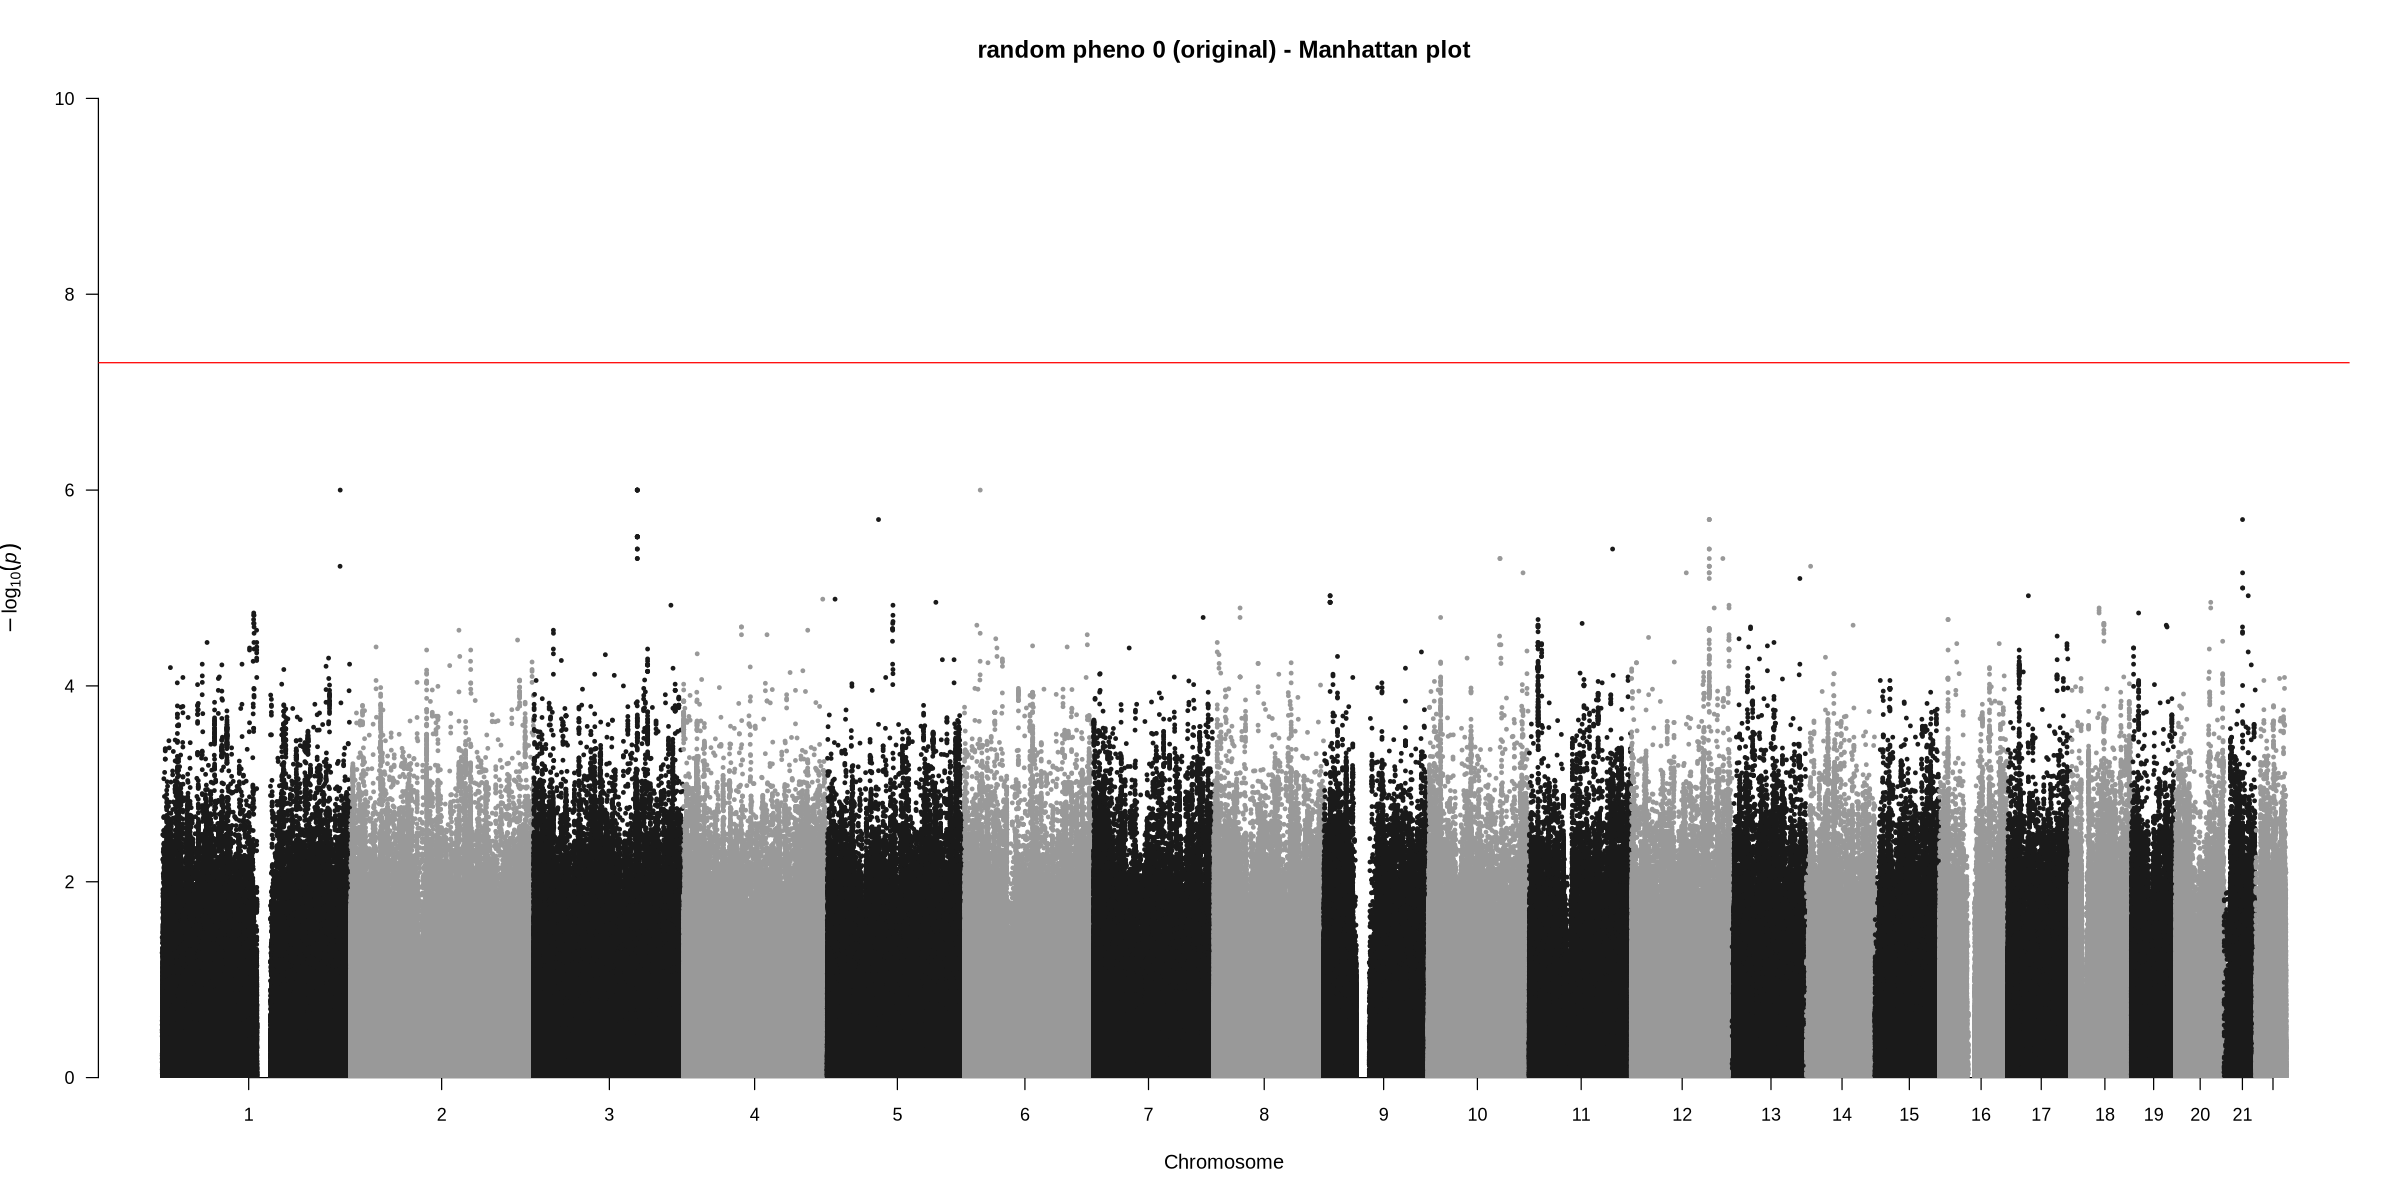

In [24]:
options(repr.plot.width = 20, repr.plot.height = 10)

manhattan(
  gwas,
  chr = "#CHROM",
  bp = "POS",
  p = "P",
  snp = "ID",
  main = paste0("random pheno ", pheno_code, " (", title_prefix, ")", " - Manhattan plot"),
  suggestiveline = F,
  genomewideline = -log10(5e-08),
  cex = 0.6,
  cex.axis = 0.9,
  ylim = c(0, max(gwas_max_mlog_noninf+1, 10)),
)

## QQ-plot

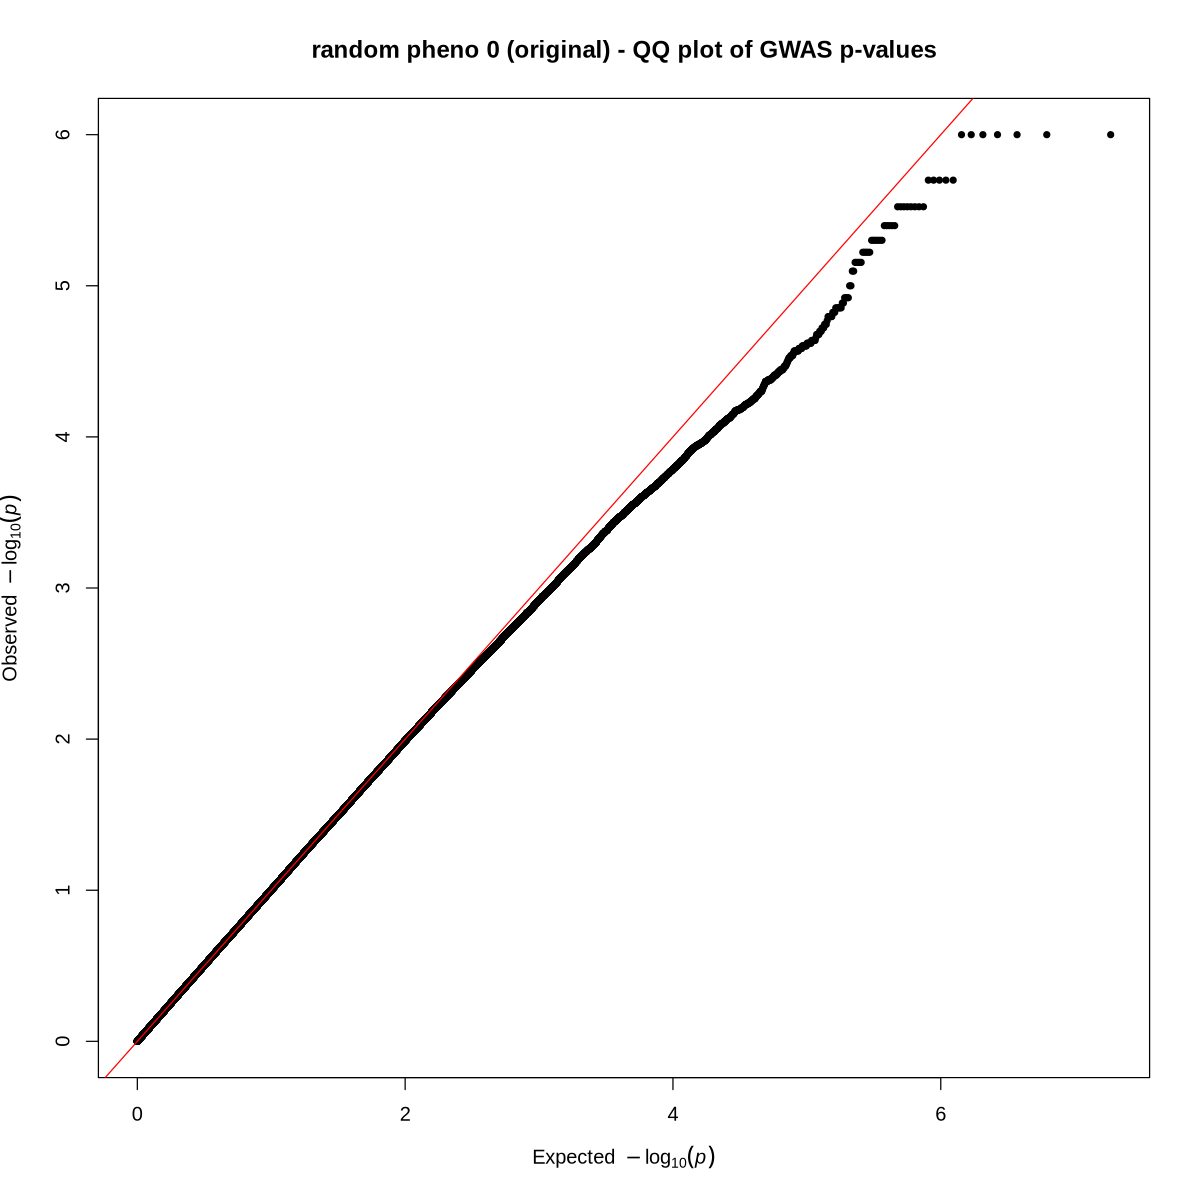

In [25]:
options(repr.plot.width = 10, repr.plot.height = 10)

qq(
    gwas$P,
    main = paste0("random pheno ", pheno_code, " (", title_prefix, ")", " - QQ plot of GWAS p-values")
)